#**SVM method**

#### Importing libraries

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.5 MB/s eta 0:00:00


In [2]:
import statistics
import numpy as np
import pandas as pd
from Bio import BiopythonWarning
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

#### Loading data

In [3]:
data_file = "/content/SVM_data.tsv"
df = pd.read_csv(data_file, sep="\t",)
df_test = df[df["dataset_class"].isin(["Test"])]
df = df[df["dataset_class"].isin(["Training"])]
df = df.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df

,protein_id,dataset_class,cv_subset,type,sequence
0,Q99MA2,Training,1,Positive,MAQAYWQCYPWLVLLCACAWSYPGPESLGREDVRDCSTNPPRLPVT...
1,P17948,Training,1,Positive,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...
2,P41271,Training,1,Positive,MMLRVLVGAVLPAMLLAAPPPINKLALFPDKSAWCEAKNITQIVGH...
3,Q8I948,Training,1,Positive,MAFRMKLVVCIVLLSTLAVMSSADVYKGGGGGRYGGGRYGGGGGYG...
4,Q92154,Training,1,Positive,MELLVLTVLLMGTGCISAPWAAWMPPKMAALSGTCVQLPCRFDYPE...
...,...,...,...,...,...
8017,Q01981,Training,5,Negative,MPQPGSSVDFSNLLNPQNNTAIPAEVSNATASATMASGASLLPPMV...
8018,Q9H3N8,Training,5,Negative,MPDTNSTINLSLSTRVTLAFFMSLVAFAIMLGNALVILAFVVDKNL...
8019,P32349,Training,5,Negative,MDELLGEALSAENQTGESTVESEKLVTPEDVMTISSLEQRTLNPDL...
8020,G5EGE9,Training,5,Negative,MDVPSSSNVTGRRKRQVLDDDEDDGFRSTPLRKVRGTKKIRPADVV...


In [4]:
df_test

,protein_id,dataset_class,cv_subset,type,sequence
0,P19801,Test,0,Positive,MPALGWAVAAILMLQTAMAEPSPGTLPRKAGVFSDLSNQELKAVHS...
1,P79263,Test,0,Positive,MKTLSPTGYGLLLVLPLLLAVLQSTTAHKNDINIYSLTVDSKVSSR...
2,P21814,Test,0,Positive,MSHRRMQLALSLVFILCGLFNSIFCEKQQHSQQHANLVLLKKISAF...
3,P29421,Test,0,Positive,MVSLRLPLILLSLLAISFSCSAAPPPVYDTEGHELSADGSYYVLPA...
4,P11590,Test,0,Positive,MKLLLCLGLTLVCIHAEEATSKGQNLNVEKINGEWFSILLASDKRE...
...,...,...,...,...,...
2000,Q9SNB7,Test,0,Negative,MQALSILPLKSGLLVGSRLEFELDCSCFVVSPKTTRKRLCFLEQAC...
2001,P56560,Test,0,Negative,MSSKCDVVVVGGGISGMAAAKLLHDSGLNVIVLEARDRVGGRTYTL...
2002,P24389,Test,0,Negative,MGLSQLWLWLKRLVIFLQVALEVATGKVLMTLFPERVKQNILAMGQ...
2003,Q86UT6,Test,0,Negative,MRWGHHLPRASWGSGFRRALQRPDDRIPFLIHWSWPLQGERPFGPP...


#### Adding signal peptide residue composition to the DataFrame

In [5]:
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

for index, row in df.iterrows():
    seq = row["sequence"][:22]
    protein_analysis = ProteinAnalysis(seq)
    amino_count = protein_analysis.count_amino_acids()
    total = sum(amino_count.values())
    for aa in amino_acids:
        proportion = amino_count.get(aa, 0) / total if total > 0 else 0
        df.at[index, f"{aa}_composition"] = proportion

for index, row in df_test.iterrows():
    seq = row["sequence"][:22]
    protein_analysis = ProteinAnalysis(seq)
    amino_count = protein_analysis.count_amino_acids()
    total = sum(amino_count.values())
    for aa in amino_acids:
        proportion = amino_count.get(aa, 0) / total if total > 0 else 0
        df_test.at[index, f"{aa}_composition"] = proportion
df

,protein_id,dataset_class,cv_subset,type,sequence,A_composition,C_composition,D_composition,E_composition,F_composition,...,M_composition,N_composition,P_composition,Q_composition,R_composition,S_composition,T_composition,V_composition,W_composition,Y_composition
0,Q99MA2,Training,1,Positive,MAQAYWQCYPWLVLLCACAWSYPGPESLGREDVRDCSTNPPRLPVT...,0.181818,0.136364,0.000000,0.000000,0.000000,...,0.045455,0.000000,0.045455,0.090909,0.000000,0.045455,0.000000,0.045455,0.136364,0.136364
1,P17948,Training,1,Positive,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,0.045455,0.090909,0.045455,0.000000,0.000000,...,0.045455,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,0.090909,0.045455,0.045455
2,P41271,Training,1,Positive,MMLRVLVGAVLPAMLLAAPPPINKLALFPDKSAWCEAKNITQIVGH...,0.181818,0.000000,0.000000,0.000000,0.000000,...,0.136364,0.000000,0.181818,0.000000,0.045455,0.000000,0.000000,0.136364,0.000000,0.000000
3,Q8I948,Training,1,Positive,MAFRMKLVVCIVLLSTLAVMSSADVYKGGGGGRYGGGRYGGGGGYG...,0.090909,0.045455,0.000000,0.000000,0.045455,...,0.136364,0.000000,0.000000,0.000000,0.045455,0.136364,0.045455,0.181818,0.000000,0.000000
4,Q92154,Training,1,Positive,MELLVLTVLLMGTGCISAPWAAWMPPKMAALSGTCVQLPCRFDYPE...,0.136364,0.045455,0.000000,0.045455,0.000000,...,0.090909,0.000000,0.045455,0.000000,0.000000,0.045455,0.090909,0.090909,0.045455,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8017,Q01981,Training,5,Negative,MPQPGSSVDFSNLLNPQNNTAIPAEVSNATASATMASGASLLPPMV...,0.045455,0.000000,0.045455,0.000000,0.045455,...,0.045455,0.181818,0.136364,0.090909,0.000000,0.136364,0.045455,0.045455,0.000000,0.000000
8018,Q9H3N8,Training,5,Negative,MPDTNSTINLSLSTRVTLAFFMSLVAFAIMLGNALVILAFVVDKNL...,0.045455,0.000000,0.045455,0.000000,0.090909,...,0.090909,0.090909,0.045455,0.000000,0.045455,0.136364,0.181818,0.045455,0.000000,0.000000
8019,P32349,Training,5,Negative,MDELLGEALSAENQTGESTVESEKLVTPEDVMTISSLEQRTLNPDL...,0.090909,0.000000,0.045455,0.227273,0.000000,...,0.045455,0.045455,0.000000,0.045455,0.000000,0.136364,0.090909,0.045455,0.000000,0.000000
8020,G5EGE9,Training,5,Negative,MDVPSSSNVTGRRKRQVLDDDEDDGFRSTPLRKVRGTKKIRPADVV...,0.000000,0.000000,0.181818,0.045455,0.000000,...,0.045455,0.045455,0.045455,0.045455,0.136364,0.136364,0.045455,0.136364,0.000000,0.000000


#### Feature extraction

In [6]:
%%capture
#Hydrophobicity feature
window_size = 5
kd_scale = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}
eis_scale = {
    "A": 0.6, "R": -2.5, "N": -0.8, "D": -0.9, "C": 0.3,
    "Q": -0.9, "E": -0.7, "G": 0.5, "H": -0.4, "I": 1.4,
    "L": 1.1, "K": -1.5, "M": 0.6, "F": 1.2, "P": 0.1,
    "S": -0.2, "T": -0.1, "W": 0.8, "Y": 0.3, "V": 1.1
}
TM_scale = {
    "A": 0.4, "R": -2.6, "N": -1.6, "D": -3.3, "C": -0.3,
    "Q": -1.8, "E": -2.9, "G": -0.2, "H": -1.4, "I": 2.0,
    "L": 1.8, "K": -3.5, "M": 1.4, "F": 2.0, "P": -1.4,
    "S": -0.5, "T": -0.3, "W": 1.5, "Y": 0.5, "V": 1.5
}


for index,row in df.iterrows():
  seq = row["sequence"][:40]
  padding_size = int(window_size/2)
  protein_analysis = ProteinAnalysis("X" * padding_size + seq + "X"*padding_size)
  KD_profile = protein_analysis.protein_scale(kd_scale, window_size)
  eis_profile = protein_analysis.protein_scale(eis_scale, window_size)
  TM_profile = protein_analysis.protein_scale(TM_scale, window_size)
  #Kite Doolittle
  df.at[index, "KD average"] = np.mean(KD_profile)
  df.at[index, "KD maximal"] = max(KD_profile)
  df.at[index, "KD std"] = np.std(KD_profile)
  #Eisemberg
  df.at[index, "Eis average"] = np.mean(eis_profile)
  df.at[index, "Eis maximal"] = max(eis_profile)
  df.at[index, "Eis std"] = np.std(eis_profile)
  #Transmembrane tendency
  df.at[index, "TM average"] = np.mean(TM_profile)
  df.at[index, "TM maximal"] = max(TM_profile)
  df.at[index, "TM std"] = np.std(TM_profile)

for index,row in df_test.iterrows():
  seq = row["sequence"][:40]
  padding_size = int(window_size/2)
  protein_analysis = ProteinAnalysis("X" * padding_size + seq + "X"*padding_size)
  KD_profile = protein_analysis.protein_scale(kd_scale, window_size)
  eis_profile = protein_analysis.protein_scale(eis_scale, window_size)
  TM_profile = protein_analysis.protein_scale(TM_scale, window_size)
  #Kite Doolittle
  df_test.at[index, "KD average"] = np.mean(KD_profile)
  df_test.at[index, "KD maximal"] = max(KD_profile)
  df_test.at[index, "KD std"] = np.std(KD_profile)
  #Eisemberg
  df_test.at[index, "Eis average"] = np.mean(eis_profile)
  df_test.at[index, "Eis maximal"] = max(eis_profile)
  df_test.at[index, "Eis std"] = np.std(eis_profile)
  #Transmembrane tendency
  df_test.at[index, "TM average"] = np.mean(TM_profile)
  df_test.at[index, "TM maximal"] = max(TM_profile)
  df_test.at[index, "TM std"] = np.std(TM_profile)

In [7]:
df

,protein_id,dataset_class,cv_subset,type,sequence,A_composition,C_composition,D_composition,E_composition,F_composition,...,Y_composition,KD average,KD maximal,KD std,Eis average,Eis maximal,Eis std,TM average,TM maximal,TM std
0,Q99MA2,Training,1,Positive,MAQAYWQCYPWLVLLCACAWSYPGPESLGREDVRDCSTNPPRLPVT...,0.181818,0.136364,0.000000,0.000000,0.000000,...,0.136364,-0.1625,3.62,1.508411,0.0980,1.04,0.483814,-0.2920,1.68,0.893597
1,P17948,Training,1,Positive,MVSYWDTGVLLCALLSCLLLTGSSSGSKLKDPELSLKGTQHIMQAG...,0.045455,0.090909,0.045455,0.000000,0.000000,...,0.045455,0.4205,3.22,1.622193,0.2125,0.84,0.415637,-0.0945,1.10,0.901887
2,P41271,Training,1,Positive,MMLRVLVGAVLPAMLLAAPPPINKLALFPDKSAWCEAKNITQIVGH...,0.181818,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.7535,2.72,1.349847,0.3110,0.88,0.376562,0.0150,1.16,0.826205
3,Q8I948,Training,1,Positive,MAFRMKLVVCIVLLSTLAVMSSADVYKGGGGGRYGGGRYGGGGGYG...,0.090909,0.045455,0.000000,0.000000,0.045455,...,0.000000,0.5555,3.92,1.697130,0.2390,1.00,0.399173,0.0860,1.36,0.721279
4,Q92154,Training,1,Positive,MELLVLTVLLMGTGCISAPWAAWMPPKMAALSGTCVQLPCRFDYPE...,0.136364,0.045455,0.000000,0.045455,0.000000,...,0.000000,1.0625,3.06,1.032678,0.4450,0.88,0.252260,0.3265,1.32,0.561042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8017,Q01981,Training,5,Negative,MPQPGSSVDFSNLLNPQNNTAIPAEVSNATASATMASGASLLPPMV...,0.045455,0.000000,0.045455,0.000000,0.045455,...,0.000000,-0.1490,1.22,0.960437,0.1090,0.52,0.246290,-0.2795,0.70,0.469755
8018,Q9H3N8,Training,5,Negative,MPDTNSTINLSLSTRVTLAFFMSLVAFAIMLGNALVILAFVVDKNL...,0.045455,0.000000,0.045455,0.000000,0.090909,...,0.000000,1.2330,3.62,1.460483,0.4275,1.08,0.453535,0.5200,1.54,0.780935
8019,P32349,Training,5,Negative,MDELLGEALSAENQTGESTVESEKLVTPEDVMTISSLEQRTLNPDL...,0.090909,0.000000,0.045455,0.227273,0.000000,...,0.000000,-0.3970,1.82,1.091362,-0.0095,0.56,0.331149,-0.6135,0.82,0.619312
8020,G5EGE9,Training,5,Negative,MDVPSSSNVTGRRKRQVLDDDEDDGFRSTPLRKVRGTKKIRPADVV...,0.000000,0.000000,0.181818,0.045455,0.000000,...,0.000000,-1.2350,0.90,1.172482,-0.4540,0.28,0.491125,-1.1225,0.40,0.850484


In [8]:
df_test

,protein_id,dataset_class,cv_subset,type,sequence,A_composition,C_composition,D_composition,E_composition,F_composition,...,Y_composition,KD average,KD maximal,KD std,Eis average,Eis maximal,Eis std,TM average,TM maximal,TM std
0,P19801,Test,0,Positive,MPALGWAVAAILMLQTAMAEPSPGTLPRKAGVFSDLSNQELKAVHS...,0.272727,0.000000,0.000000,0.045455,0.000000,...,0.000000,0.3430,3.22,1.374529,0.2380,0.96,0.435059,-0.0585,1.48,0.806305
1,P79263,Test,0,Positive,MKTLSPTGYGLLLVLPLLLAVLQSTTAHKNDINIYSLTVDSKVSSR...,0.045455,0.000000,0.000000,0.000000,0.000000,...,0.045455,0.5845,3.88,1.648524,0.2945,1.10,0.467995,0.1115,1.74,0.894851
2,P21814,Test,0,Positive,MSHRRMQLALSLVFILCGLFNSIFCEKQQHSQQHANLVLLKKISAF...,0.045455,0.045455,0.000000,0.000000,0.090909,...,0.000000,0.2740,3.82,2.144296,0.1175,1.18,0.663870,-0.0365,1.82,1.096503
3,P29421,Test,0,Positive,MVSLRLPLILLSLLAISFSCSAAPPPVYDTEGHELSADGSYYVLPA...,0.090909,0.045455,0.000000,0.000000,0.045455,...,0.000000,0.5870,3.02,1.493978,0.2870,0.96,0.359710,-0.0040,1.38,0.846962
4,P11590,Test,0,Positive,MKLLLCLGLTLVCIHAEEATSKGQNLNVEKINGEWFSILLASDKRE...,0.090909,0.090909,0.000000,0.090909,0.000000,...,0.000000,0.4225,3.54,1.667238,0.2350,0.94,0.432868,-0.0905,1.42,0.916711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,Q9SNB7,Test,0,Negative,MQALSILPLKSGLLVGSRLEFELDCSCFVVSPKTTRKRLCFLEQAC...,0.045455,0.000000,0.000000,0.090909,0.045455,...,0.000000,0.3595,2.62,1.450155,0.0705,0.86,0.551761,-0.2340,1.10,0.825436
2001,P56560,Test,0,Negative,MSSKCDVVVVGGGISGMAAAKLLHDSGLNVIVLEARDRVGGRTYTL...,0.136364,0.045455,0.045455,0.000000,0.000000,...,0.000000,0.6145,3.28,1.380268,0.2155,0.98,0.507691,-0.1075,1.16,0.801270
2002,P24389,Test,0,Negative,MGLSQLWLWLKRLVIFLQVALEVATGKVLMTLFPERVKQNILAMGQ...,0.045455,0.000000,0.000000,0.045455,0.045455,...,0.000000,0.6535,3.82,1.349010,0.2410,1.18,0.474952,0.1480,1.82,0.852171
2003,Q86UT6,Test,0,Negative,MRWGHHLPRASWGSGFRRALQRPDDRIPFLIHWSWPLQGERPFGPP...,0.090909,0.000000,0.000000,0.000000,0.045455,...,0.000000,-0.7500,2.80,1.168007,-0.0890,1.04,0.514295,-0.3985,1.28,0.849840


#### Spliting into training and validation

In [9]:
indexes_dict = df.groupby('cv_subset').groups
validation = list(indexes_dict[1])
training = []
for i in range(2, 6):
    training.extend(list(indexes_dict[i]))

# Correctly define the test set indices from df_test
indexes_dict_test = df_test.groupby('cv_subset').groups # Use df_test here
test = list(indexes_dict_test[0]) # df_test has cv_subset=0


#### Columns of the DataFrame to omit during training

In [10]:
cols_to_exclude = ['sequence', 'dataset_class', 'cv_subset', 'type', "protein_id"]

X = df.loc[:, ~df.columns.isin(cols_to_exclude)]
y = df['type'].map({'Positive': 1, 'Negative': 0}).values
X_t = df_test.loc[:, ~df_test.columns.isin(cols_to_exclude)]
y_t = df_test['type'].map({'Positive': 1, 'Negative': 0}).values


#### Execution with feature selection using ElasticNet

In [11]:
# We'll use a simple StandardScaler + RBF SVM pipeline
def svm_pipeline(C, gamma):
    return Pipeline([
        ("svm", SVC(kernel="rbf", C=C, gamma=gamma, random_state=42))
    ])

# Minimal manual grid
C_grid = [0.1, 1.0, 10.0, 100.0]
gamma_grid = ["scale", 0.01, 0.1, 1.0]

metrics_tot_en = []
features_tot_en = []





X_train = X.loc[training]
y_train = y[training]
X_val = X.loc[validation]
y_val = y[validation]
X_test = X_t.loc[test]
y_test = y_t[test]
best_mcc = -np.inf
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
#feature selection
model_feature_sel = LogisticRegressionCV(
  penalty='elasticnet',
  l1_ratios=[0.1, 0.5, 0.7, 0.9, 1.0],
  cv=3,
  solver='saga',
  random_state=42,
  max_iter=5000,
)
selector = SelectFromModel(model_feature_sel, threshold="median")
selector.fit(X_train_scaled, y_train)
selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()
print(f"Selected features by ElasticNet: {selected_features}")
features_tot_en.append(selected_features)
#scaling
X_train_selected = selector.transform(X_train_scaled)
X_val_selected = selector.transform(X_val_scaled)
X_test_selected = selector.transform(X_test_scaled)
#grid search
for C in C_grid:
    for gamma in gamma_grid:
        pipe = svm_pipeline(C, gamma)
        pipe.fit(X_train_selected, y_train)
        y_pred_val = pipe.predict(X_val_selected)

        mcc_val = matthews_corrcoef(y_val, y_pred_val)
        if mcc_val > best_mcc:
              best_mcc = mcc_val
              actual_gamma = pipe.named_steps['svm']._gamma
              best_c_val = C
              best_gamma_val = actual_gamma
#metrics
pipe = svm_pipeline(best_c_val, best_gamma_val)
pipe.fit(X_train_selected, y_train)
y_pred_test = pipe.predict(X_test_selected)
acc = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, zero_division=0)
recall = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred_test)
metrics_tot_en.append([precision, recall, f1, acc, mcc, best_c_val, best_gamma_val])
print(f"Best validation MCC: {best_mcc:.3f} with params C: {best_c_val:.2f} - gamma: {best_gamma_val:.4f}")
print(f"Accuracy: {acc:.3f} - Precision: {precision:.3f} - Recall: {recall:.3f} - F1: {f1:.3f} - MCC: {mcc:.3f} \n")

Selected features by ElasticNet: ['A_composition', 'D_composition', 'E_composition', 'K_composition', 'L_composition', 'N_composition', 'P_composition', 'W_composition', 'KD average', 'KD std', 'Eis average', 'Eis maximal', 'Eis std', 'TM average', 'TM maximal']
Best validation MCC: 0.818 with params C: 100.00 - gamma: 0.0100
Accuracy: 0.970 - Precision: 0.849 - Recall: 0.876 - F1: 0.862 - MCC: 0.845 



In [12]:
TP ,TN, FP, FN = 0,0,0,0
for i in range(len(y_pred_test)):
  if y_t[i] == 0:
    if y_pred_test[i] == 0:
      TN += 1
    else:
      FN += 1
  else:
    if y_pred_test[i] == 0:
      FP += 1
    else:
      TP += 1

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

TP: 191, TN: 1753, FP: 27, FN: 34


In [13]:
test_index = df_test.index



tp_mask = (y_test == 1) & (y_pred_test == 1)
tp_indexes = test_index[tp_mask].tolist()


tn_mask = (y_test == 0) & (y_pred_test == 0)
tn_indexes = test_index[tn_mask].tolist()


fp_mask = (y_test == 0) & (y_pred_test == 1)
fp_indexes = test_index[fp_mask].tolist()


fn_mask = (y_test == 1) & (y_pred_test == 0)
fn_indexes = test_index[fn_mask].tolist()

# Output di verifica
print(f"Counts -> TP: {len(tp_indexes)}, TN: {len(tn_indexes)}, FP: {len(fp_indexes)}, FN: {len(fn_indexes)}")
print(f"False Positives Indexes (FP): {fp_indexes}")
print(f"False Negatives Indexes(FN): {fn_indexes}")
print(f"True Positives Indexes (FP): {tp_indexes}")
print(f"True Negatives Indexes(FN): {tn_indexes}")

Counts -> TP: 191, TN: 1753, FP: 34, FN: 27
False Positives Indexes (FP): [226, 231, 263, 306, 310, 337, 402, 418, 484, 496, 565, 629, 748, 839, 868, 906, 909, 958, 1045, 1064, 1132, 1136, 1210, 1260, 1293, 1403, 1449, 1511, 1680, 1695, 1766, 1783, 1983, 2002]
False Negatives Indexes(FN): [14, 20, 27, 52, 68, 71, 78, 97, 128, 143, 144, 145, 146, 148, 149, 151, 167, 171, 174, 178, 184, 197, 199, 206, 213, 214, 216]
True Positives Indexes (FP): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 69, 70, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,

In [31]:
positive = pd.read_csv("/content/positive_set.tsv", sep="\t")
negative = pd.read_csv("/content/negative_set.tsv", sep="\t")
raw_df = tot = pd.concat([positive, negative])

cols_to_add = ['protein_id', 'organism_name', 'kingdom', 'TM_helix_presence','pos_cleavage_site']
raw_df = raw_df[cols_to_add]
df_test = pd.merge(df_test, raw_df, on='protein_id', how='left')
df = pd.merge(df, raw_df, on='protein_id', how='left')


In [17]:
tp = df_test.loc[tp_indexes]
fn = df_test.loc[fn_indexes]
fn


,protein_id,dataset_class,cv_subset,type,sequence,A_composition,C_composition,D_composition,E_composition,F_composition,...,Eis average,Eis maximal,Eis std,TM average,TM maximal,TM std,organism_name,kingdom,TM_helix_presence,pos_cleavage_site
14,Q10NX8,Test,0,Positive,MAAATVGVLLRLLLLPVVVVVSLLVGASRAANVTYDHRAVVIDGVR...,0.136364,0.000000,0.000000,0.000000,0.000000,...,0.3745,1.10,0.480770,0.3940,1.50,0.762656,Oryza sativa subsp. japonica,Viridiplantae,NaN,30.0
20,Q16927,Test,0,Positive,MATDGITSRFGFNERRRTHNRNSCRILEDKMLAKLLLLALAGLTAA...,0.045455,0.000000,0.045455,0.045455,0.090909,...,-0.2225,1.00,0.686938,-0.5200,1.52,0.953562,Aedes aegypti,Metazoa,NaN,46.0
27,P12024,Test,0,Positive,MGLEFFFKFGYAFLTITLMIMIWMSLARASMFDREMEETHYPPCTY...,0.045455,0.000000,0.000000,0.045455,0.227273,...,0.2990,1.02,0.504400,0.2770,1.72,0.974921,Drosophila melanogaster,Metazoa,NaN,29.0
52,Q42656,Test,0,Positive,MVKSPGTEDYTRRSLLANGLGLTPPMGWNSWNHFRCNLDEKLIRET...,0.045455,0.000000,0.045455,0.045455,0.000000,...,-0.0590,0.62,0.429650,-0.4480,0.58,0.643052,Coffea arabica,Viridiplantae,NaN,15.0
68,Q9NPG1,Test,0,Positive,MAMTWIVFSLWPLTVFMGHIGGHSLFSCEPITLRMCQDLPYNTTFM...,0.045455,0.000000,0.000000,0.000000,0.090909,...,0.3775,0.92,0.341209,0.2930,1.36,0.676647,Homo sapiens,Metazoa,NaN,22.0
71,Q56S59,Test,0,Positive,MASAKIFLIFLLAALIATPAAFAILVPTLVSTHISGLVFCSVNGNL...,0.318182,0.000000,0.000000,0.000000,0.136364,...,0.6200,1.26,0.332716,0.6765,1.96,0.603223,Nicotiana tabacum,Viridiplantae,NaN,23.0
78,Q9UBN6,Test,0,Positive,MGLWGQSVPTASSARAGRYPGARTASGTRPWLLDPKILKFVVFIVA...,0.181818,0.000000,0.000000,0.000000,0.000000,...,-0.0150,0.70,0.309734,-0.3425,0.86,0.465235,Homo sapiens,Metazoa,NaN,55.0
97,I6S7G5,Test,0,Positive,MSWMFYSFIVFTLAIKEVIAIDGLEICSNDQLHVTIYSIFSPLFDK...,0.090909,0.000000,0.045455,0.045455,0.136364,...,0.4125,0.96,0.355716,0.2915,1.44,0.785543,Scolopendra mutilans,Metazoa,NaN,16.0
128,O35701,Test,0,Positive,MLLSAPLRHLPGLLLLLWPLLLLPSLAAPGRLARASVRRLGTRVPG...,0.045455,0.000000,0.000000,0.000000,0.000000,...,0.2770,1.10,0.548462,0.2725,1.80,0.750316,Mus musculus,Metazoa,NaN,27.0
143,O15455,Test,0,Positive,MRQTLPCIYFWGGLLPFGMLCASSTTKCTVSHEVADCSHLKLTQVP...,0.045455,0.090909,0.000000,0.000000,0.090909,...,0.2515,0.84,0.416074,-0.0050,1.16,0.707301,Homo sapiens,Metazoa,NaN,23.0


In [18]:
fp = df_test.loc[fp_indexes]
fp

,protein_id,dataset_class,cv_subset,type,sequence,A_composition,C_composition,D_composition,E_composition,F_composition,...,Eis average,Eis maximal,Eis std,TM average,TM maximal,TM std,organism_name,kingdom,TM_helix_presence,pos_cleavage_site
226,Q9VSB9,Test,0,Negative,MASLSETLRSHWPIALFGVILFVAGGTELYWNEGRAVHNMMALDEA...,0.090909,0.000000,0.000000,0.045455,0.090909,...,0.2645,1.18,0.516614,0.1070,1.76,0.813296,Drosophila melanogaster,Metazoa,True,NaN
231,P26434,Test,0,Negative,MGPAMLRAFSSWKWLLLLMVLTCLEASSYVNESSSPTGQQTPDARF...,0.090909,0.000000,0.000000,0.000000,0.045455,...,0.2140,1.04,0.385284,0.0765,1.74,0.786701,Rattus norvegicus,Metazoa,True,NaN
263,Q9JK95,Test,0,Negative,MLRCGLACERCRWILPLLLLSAIAFDIIALAGRGWLQSSNHIQTSS...,0.090909,0.136364,0.000000,0.045455,0.000000,...,0.2720,1.02,0.517761,0.2200,1.34,0.732079,Mus musculus,Metazoa,True,NaN
306,Q9UJ42,Test,0,Negative,MTALSSENCSFQYQLRQTNQPLDVNYLLFLIILGKILLNILTLGMR...,0.045455,0.045455,0.000000,0.045455,0.045455,...,0.1820,1.24,0.541568,0.0210,1.92,0.927642,Homo sapiens,Metazoa,True,NaN
310,P24613,Test,0,Negative,MASATLAFSCSSLCATLKLPQNLNPLLLNVPPLSKPFSGVVSPPSL...,0.181818,0.090909,0.000000,0.000000,0.045455,...,0.2500,0.72,0.262374,-0.0080,1.06,0.555982,Spinacia oleracea,Viridiplantae,False,NaN
337,Q90578,Test,0,Negative,MTLERLWQVLDPLWADPRVLSALFCGSAMAVVLLKRLGHRRIQQKM...,0.090909,0.000000,0.090909,0.045455,0.000000,...,0.1740,1.00,0.455241,0.0315,1.40,0.689737,Gallus gallus,Metazoa,False,NaN
402,Q9FPS9,Test,0,Negative,MLEPRGADIPILFLVLVVLPVVAYILLGKWSNISEKRVRANLLAQM...,0.045455,0.000000,0.045455,0.045455,0.045455,...,0.3095,1.18,0.648136,0.1445,1.82,1.088986,Arabidopsis thaliana,Viridiplantae,False,NaN
418,Q16617,Test,0,Negative,MELCRSLALLGGSLGLMFCLIALSTDFWFEAVGPTHSAHSGLWPTG...,0.090909,0.090909,0.000000,0.045455,0.045455,...,0.3780,0.92,0.371559,0.2620,1.38,0.654932,Homo sapiens,Metazoa,True,NaN
484,P78780,Test,0,Negative,MAIKKVGILGATGTVGQRFITLLSDHPEFKIAVLGASARSAGKPYA...,0.090909,0.000000,0.000000,0.000000,0.045455,...,0.2285,0.94,0.393977,-0.0490,1.46,0.738268,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,False,NaN
496,Q9SS48,Test,0,Negative,MSLASIRRLAAGAAVIAAASGGAVYLSPSVASSDKGGGPILDSLRR...,0.363636,0.000000,0.000000,0.000000,0.000000,...,0.2700,0.86,0.419881,0.0335,0.94,0.684169,Arabidopsis thaliana,Viridiplantae,False,NaN


In [19]:
# import data
fp_kingdom = fp['kingdom'].value_counts()
fn_kingdom = fn['kingdom'].value_counts()
fp_species = fp['organism_name'].value_counts()
fn_species = fn['organism_name'].value_counts()
k_colors = sns.color_palette("pastel", len(fn_kingdom))
s_colors = sns.color_palette("pastel", len(fn_species))

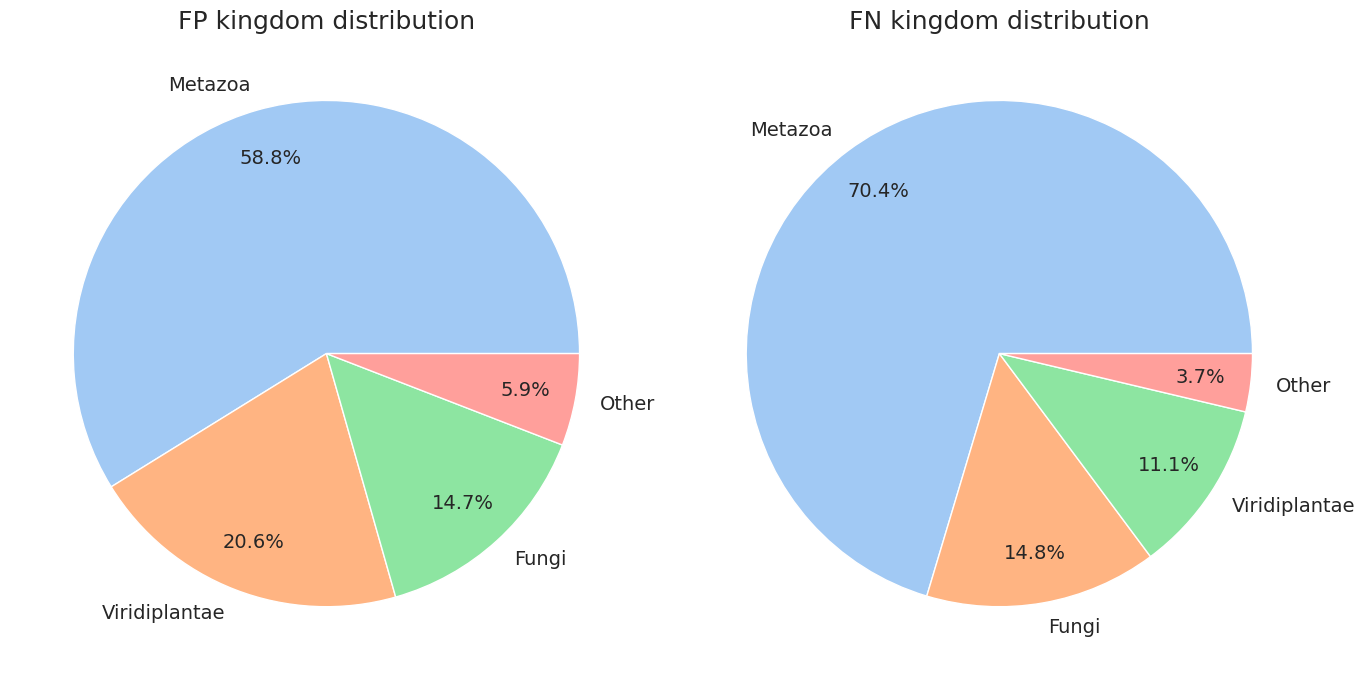

In [20]:
# filter kingdom data
def filter_kingdom(kingdom):
  kingdom_top = kingdom.head(3)
  k_other_sum = kingdom.iloc[3:].sum()
  k_other_series = pd.Series({"Other": k_other_sum})
  kingdom_grouped = pd.concat([kingdom_top, k_other_series])
  return kingdom_grouped
fp_k_grouped = filter_kingdom(fp_kingdom)
fn_k_grouped = filter_kingdom(fn_kingdom)

# kingdom piecharts
kingdom_fig, (kingdom_ax1, kingdom_ax2) = plt.subplots(1,2, figsize=(14, 7))
kingdom_ax1.pie(
    fp_k_grouped.values,
    labels=fp_k_grouped.index,
    autopct='%1.1f%%',
    colors=k_colors,
    textprops={'fontsize': 14},
    pctdistance=0.8,
)
kingdom_ax1.set_title("FP kingdom distribution", fontsize=18)

kingdom_ax2.pie(
    fn_k_grouped.values,
    labels=fn_k_grouped.index,
    autopct='%1.1f%%',
    colors=k_colors,
    textprops={'fontsize': 14},
    pctdistance=0.8,
)
kingdom_ax2.set_title("FN kingdom distribution", fontsize=18)

kingdom_fig.tight_layout()
kingdom_fig.savefig("kingdom_piechart.png")


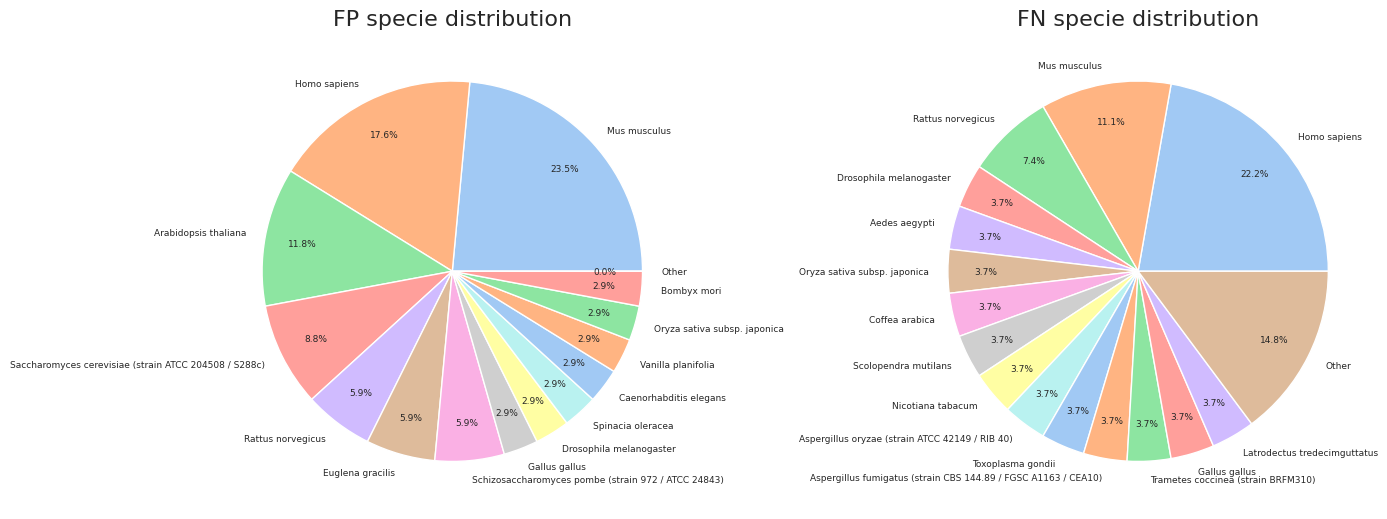

In [21]:
# filter species data
def filter_species(species):
  species_top = species.head(15)
  s_other_sum = species.iloc[15:].sum()
  s_other_series = pd.Series({"Other": s_other_sum})
  species_grouped = pd.concat([species_top, s_other_series])
  return species_grouped
fp_s_grouped = filter_species(fp_species)
fn_s_grouped = filter_species(fn_species)

# species piecharts
specie_fig, (specie_ax1, specie_ax2) = plt.subplots(1,2, figsize=(14, 7))
specie_ax1.pie(
    fp_s_grouped.values,
    labels=fp_s_grouped.index,
    autopct='%1.1f%%',
    colors=s_colors,
    textprops={'fontsize': 6.5},
    pctdistance=0.8
)
specie_ax1.set_title("FP specie distribution", fontsize=16)

specie_ax2.pie(
    fn_s_grouped.values,
    labels=fn_s_grouped.index,
    autopct='%1.1f%%',
    colors=s_colors,
    textprops={'fontsize': 6.5},
    pctdistance=0.8,
)
specie_ax2.set_title("FN specie distribution", fontsize=16)

specie_fig.tight_layout()
specie_fig.savefig("species_piechart.png")


In [22]:
TM_fp_count = fp['TM_helix_presence'].value_counts()
negative_vc = negative.query('TM_helix_presence == True')
TM_fp_count

,count
TM_helix_presence,
False,19
True,15


In [23]:
negative_vc

,protein_id,organism_name,kingdom,protein_length,TM_helix_presence,class,cv_subset
2,P21145,Homo sapiens,Metazoa,153,True,Training,1
7,F4JYC8,Arabidopsis thaliana,Viridiplantae,1706,True,Training,1
17,Q99679,Homo sapiens,Metazoa,349,True,Training,1
20,Q9DCX7,Mus musculus,Metazoa,243,True,Training,1
27,P52591,Rattus norvegicus,Metazoa,1199,True,Training,1
...,...,...,...,...,...,...,...
8912,H9JBU5,Bombyx mori,Metazoa,157,True,Test,0
8919,O55242,Mus musculus,Metazoa,223,True,Test,0
8924,Q9C900,Arabidopsis thaliana,Viridiplantae,193,True,Test,0
8930,P56560,Bos taurus,Metazoa,520,True,Test,0


In [24]:
#fp/(tn+fp)
FPR = FP/(FP+TN)
print(FPR)
#FPRtm = FPtm / (Ntm)
FRPtm = TM_fp_count.get(True,0) / len(negative_vc)
print(FRPtm)
#

0.015168539325842697
0.010964912280701754


In [25]:
fn_aa_freq = {}
for aa in amino_acids:
  fn_aa_freq[aa] = fn[f"{aa}_composition"].mean()
print(fn_aa_freq)

{'A': np.float64(0.12626262626262624), 'C': np.float64(0.016835016835016838), 'D': np.float64(0.01346801346801347), 'E': np.float64(0.02693602693602693), 'F': np.float64(0.057239057239057235), 'G': np.float64(0.058922558922558925), 'H': np.float64(0.008417508417508419), 'I': np.float64(0.05892255892255892), 'K': np.float64(0.016835016835016838), 'L': np.float64(0.15151515151515152), 'M': np.float64(0.07407407407407406), 'N': np.float64(0.016835016835016835), 'P': np.float64(0.048821548821548814), 'Q': np.float64(0.018518518518518517), 'R': np.float64(0.0606060606060606), 'S': np.float64(0.07070707070707069), 'T': np.float64(0.062289562289562284), 'V': np.float64(0.06397306397306397), 'W': np.float64(0.028619528619528625), 'Y': np.float64(0.0202020202020202)}


In [26]:
tp_aa_freq = {}
for aa in amino_acids:
  tp_aa_freq[aa] = tp[f"{aa}_composition"].mean()
print(tp_aa_freq)

{'A': np.float64(0.14516896715849595), 'C': np.float64(0.032841504045692534), 'D': np.float64(0.012613041408852927), 'E': np.float64(0.014040932889100428), 'F': np.float64(0.052594002855782966), 'G': np.float64(0.05521180390290339), 'H': np.float64(0.011661113755354594), 'I': np.float64(0.046882436934792965), 'K': np.float64(0.023322227510709188), 'L': np.float64(0.22560685387910517), 'M': np.float64(0.06425511661113756), 'N': np.float64(0.00880533079485959), 'P': np.float64(0.0390290337934317), 'Q': np.float64(0.020942408376963352), 'R': np.float64(0.025940028557829606), 'S': np.float64(0.07353641123274632), 'T': np.float64(0.04117087101380296), 'V': np.float64(0.0825797239409805), 'W': np.float64(0.013326987148976678), 'Y': np.float64(0.010471204188481676)}


In [27]:
training_positives = df[df["type"].isin(["Positive"])]
training_positives  = training_positives.reset_index(drop=True)
training_positives
training_positives_freq = {}
for aa in amino_acids:
  training_positives_freq[aa] = training_positives[f"{aa}_composition"].mean()
print(training_positives_freq)

{'A': np.float64(0.13137662337662337), 'C': np.float64(0.028883116883116886), 'D': np.float64(0.011783549783549783), 'E': np.float64(0.01683116883116883), 'F': np.float64(0.051982683982683985), 'G': np.float64(0.054597402597402596), 'H': np.float64(0.012207792207792207), 'I': np.float64(0.04690909090909091), 'K': np.float64(0.024415584415584415), 'L': np.float64(0.2167445887445887), 'M': np.float64(0.06516883116883117), 'N': np.float64(0.011584415584415584), 'P': np.float64(0.041038961038961035), 'Q': np.float64(0.02098701298701299), 'R': np.float64(0.032207792207792206), 'S': np.float64(0.07265800865800866), 'T': np.float64(0.046857142857142854), 'V': np.float64(0.08410389610389611), 'W': np.float64(0.017818181818181816), 'Y': np.float64(0.011844155844155844)}


In [29]:
tp_amino_dist = pd.DataFrame(tp_aa_freq, index=["TP"])
fn_amino_dist = pd.DataFrame(fn_aa_freq, index=["FN"])
training_positives_dist = pd.DataFrame(training_positives_freq, index=["Training positives"])
amino_distribution = pd.concat([tp_amino_dist, fn_amino_dist, training_positives_dist])
amino_distribution_long = amino_distribution.reset_index(names='Set').melt(id_vars='Set', var_name='aa', value_name='Percentage')
amino_distribution_long.head(20)

,Set,aa,Percentage
0,TP,A,0.145169
1,FN,A,0.126263
2,Training positives,A,0.131377
3,TP,C,0.032842
4,FN,C,0.016835
5,Training positives,C,0.028883
6,TP,D,0.012613
7,FN,D,0.013468
8,Training positives,D,0.011784
9,TP,E,0.014041


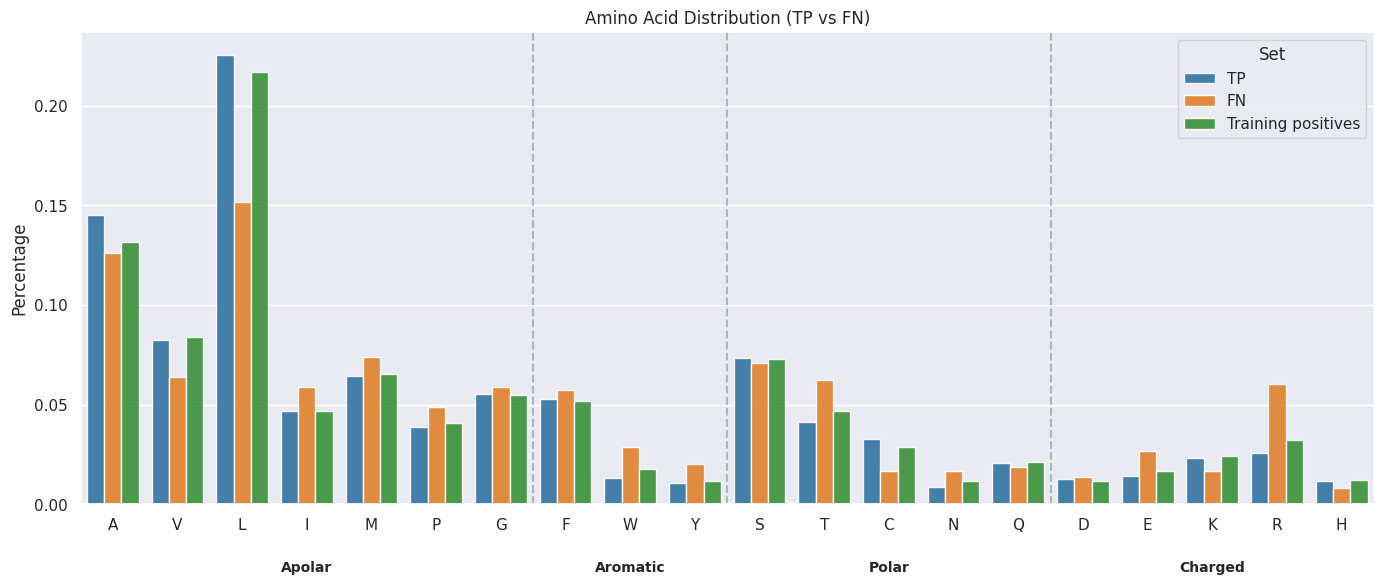

In [47]:
# --- Blocco Grafico Modificato ---

# 1. Definiamo l'ordine e i gruppi degli amminoacidi
# (Puoi spostare gli AA se preferisci una classificazione diversa)
aa_groups = {
    "Apolar":   ["A", "V", "L", "I", "M", "P", "G"],
    "Aromatic": ["F", "W", "Y"],
    "Polar":    ["S", "T", "C", "N", "Q"],
    "Charged":  ["D", "E", "K", "R", "H"]
}

# Creiamo una lista piatta ordinata per il grafico
aa_order = []
for group in aa_groups.values():
    aa_order.extend(group)

plt.figure(figsize=(14, 6))

# 2. Creiamo un UNICO grafico
# Passiamo 'aa_order' al parametro 'order' per raggrupparli visivamente
ax = sns.barplot(data=amino_distribution_long[amino_distribution_long["Set"].isin(["TP","FN","Training positives"])],
                 x="aa",
                 y="Percentage",
                 hue="Set",
                  palette = ["#1f77b4", "#ff7f0e", "#2ca02c"],
                 order=aa_order,  # Fondamentale per l'ordine
                 edgecolor="white",
                 alpha=0.9)

ax.set_title("Amino Acid Distribution (TP vs FN)")
ax.set_xlabel("") # Rimuoviamo l'etichetta generica per fare spazio ai gruppi

# 3. Aggiungiamo le etichette dei gruppi e linee separatrici
# Calcoliamo dove posizionare le scritte
start = -0.5
y_min, y_max = ax.get_ylim()

for label, amino_list in aa_groups.items():
    n_aa = len(amino_list)
    center = start + (n_aa / 2)

    # Aggiungiamo il testo del gruppo sotto l'asse X
    # y = -0.15 * y_max posiziona il testo sotto le etichette degli assi (aggiusta se serve)
    ax.text(center, -0.12 * y_max, label,
            ha='center', va='top', fontweight='bold', fontsize=10)

    # Aggiungiamo linee verticali per separare i gruppi
    end = start + n_aa
    if end < len(aa_order): # Non disegniamo l'ultima linea
        plt.axvline(x=end, color='gray', linestyle='--', alpha=0.5)

    start = end

plt.tight_layout()
#plt.show()
plt.savefig("aa_frequencies_combined.png")

In [32]:
values_tp = tp['pos_cleavage_site'].tolist() # o 'pos_cleavage_site'
values_fn = fn['pos_cleavage_site'].tolist()
values_training_positives = df['pos_cleavage_site'].tolist()

In [36]:
temp_tp = pd.DataFrame({'Value': values_tp, 'Set': 'TP'})
temp_fn = pd.DataFrame({'Value': values_fn, 'Set': 'FN'})
temp_training_positives = pd.DataFrame({'Value': values_training_positives, 'Set': 'training_positives'})
sp_data = pd.concat([temp_tp, temp_fn, temp_training_positives], ignore_index=True)

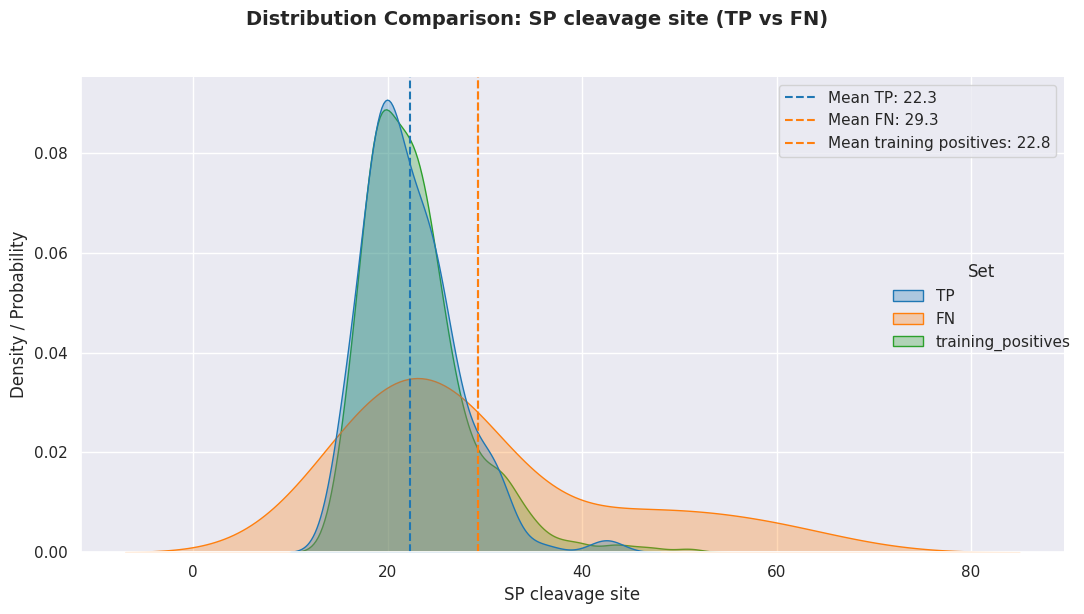

In [44]:
g = sns.displot(data=sp_data,
                x="Value",
                hue="Set",
                kind="kde",       # Usa "hist" se preferisci le barre, "kde" per le curve
                fill=True,        # Riempie il colore sotto la curva
                common_norm=False,
                palette = ["#1f77b4", "#ff7f0e", "#2ca02c"],# Normalizza ogni curva indipendentemente (area=1 per ognuna)
                alpha=0.3,        # Trasparenza
                height=6,
                aspect=1.5)
metric_name = "SP cleavage site"

g.fig.suptitle(f'Distribution Comparison: {metric_name} (TP vs FN)', y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels(f"{metric_name}", "Density / Probability")


mean_tp = sp_data[sp_data['Set']=='TP']['Value'].mean()
mean_fn = sp_data[sp_data['Set']=='FN']['Value'].mean()
mean_training_positives = sp_data[sp_data['Set']=='training_positives']['Value'].mean()
plt.axvline(mean_tp, color='#1f77b4', linestyle='--', label=f'Mean TP: {mean_tp:.1f}')
plt.axvline(mean_fn, color='#ff7f0e', linestyle='--', label=f'Mean FN: {mean_fn:.1f}')
plt.axvline(mean_fn, color='#ff7f0e', linestyle='--', label=f'Mean training positives: {mean_training_positives:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_comparison(ax, feature_name, df_tp, df_fn, df):
    """
    Funzione helper per plottare KDE e medie su un asse specifico (ax)
    """
    # 1. Preparazione Dati (Long format al volo)
    d_tp = pd.DataFrame({'Value': df_tp[feature_name], 'Set': 'TP'})
    d_fn = pd.DataFrame({'Value': df_fn[feature_name], 'Set': 'FN'})
    d_training_positives = pd.DataFrame({'Value': df[feature_name], 'Set': 'Training_positives'})
    plot_data = pd.concat([d_tp, d_fn, d_training_positives], ignore_index=True)

    # 2. Plot KDE (equivalente al tuo displot kind='kde')
    sns.kdeplot(data=plot_data, x="Value", hue="Set",
                fill=True, common_norm=False,
                palette=["#1f77b4", "#ff7f0e", "#2ca02c"], alpha=0.3, ax=ax)

    # 3. Linee delle Medie
    mean_tp = d_tp['Value'].mean()
    mean_fn = d_fn['Value'].mean()
    mean_training_positives = d_training_positives['Value'].mean()

    ax.axvline(mean_tp, color='#1f77b4', linestyle='--', label=f'Mean TP: {mean_tp:.2f}')
    ax.axvline(mean_fn, color='#ff7f0e', linestyle='--', label=f'Mean FN: {mean_fn:.2f}')
    ax.axvline(mean_fn, color="#2ca02c", linestyle='--', label=f'Mean Training positives: {mean_training_positives:.2f}')

    # 4. Cosmetica
    ax.set_title(f"Distribution: {feature_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Density")
    ax.legend()

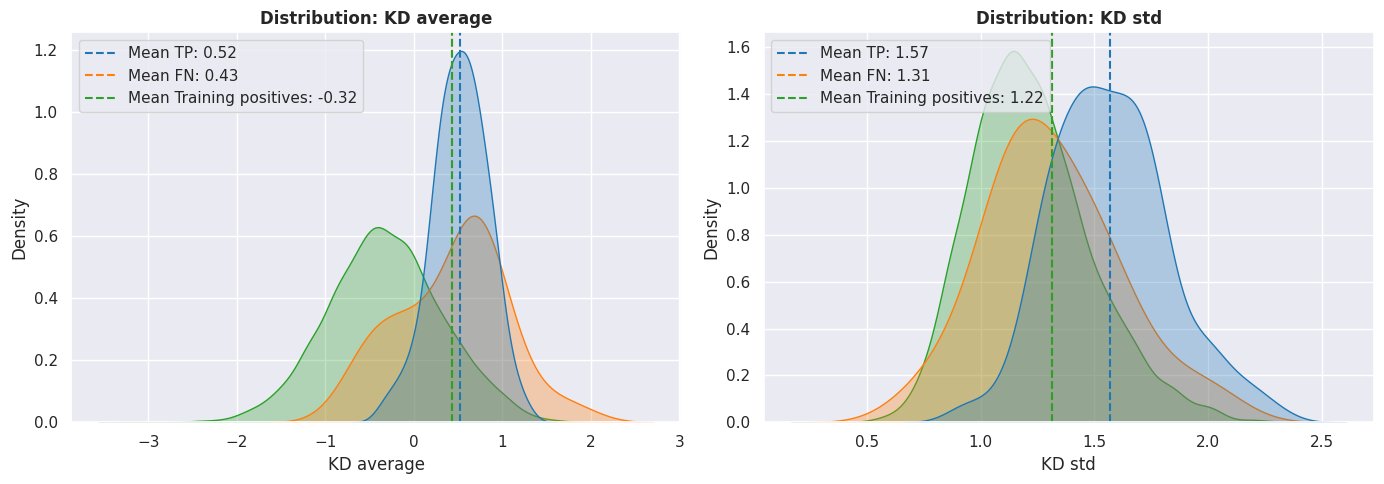

In [54]:
# Creiamo una griglia 1 riga x 2 colonne
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: KD average
plot_feature_comparison(axes[0], 'KD average', tp, fn, df)

# Plot 2: KD std
plot_feature_comparison(axes[1], 'KD std', tp, fn, df)

plt.tight_layout()
plt.savefig("KD_distributions_comparison.png")
plt.show()

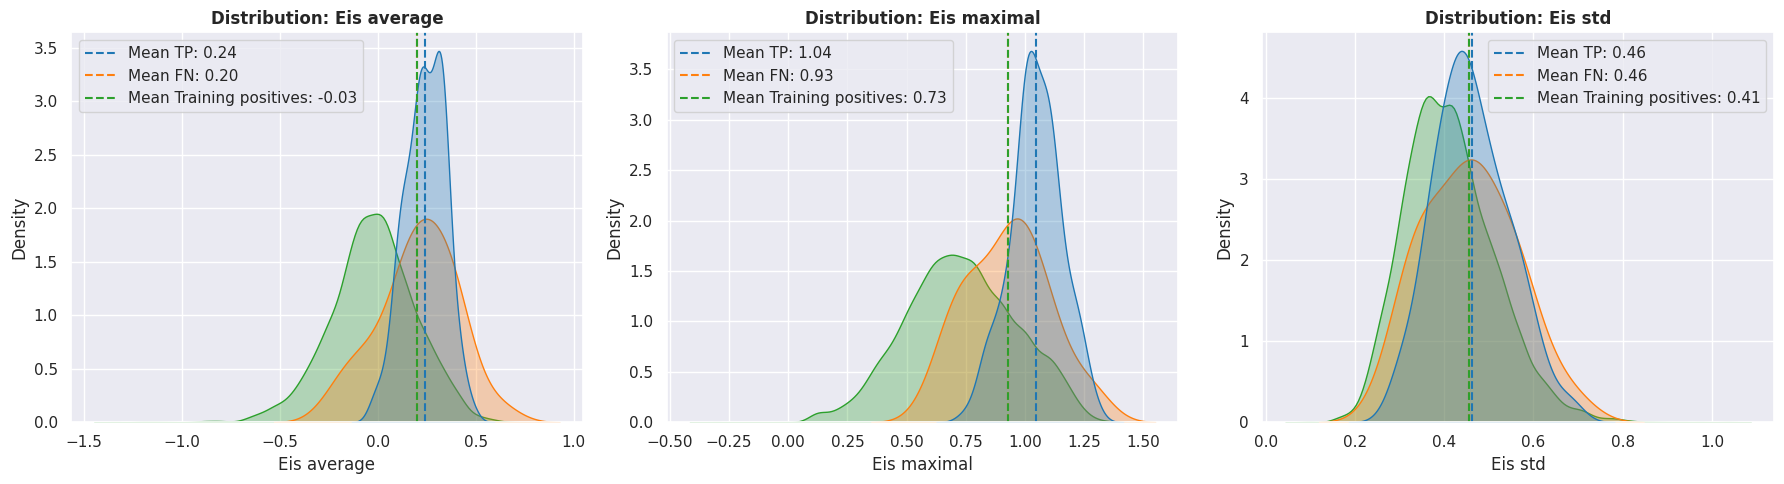

In [56]:
# Creiamo una griglia 1 riga x 3 colonne
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1, 2, 3
plot_feature_comparison(axes[0], 'Eis average', tp, fn, df)
plot_feature_comparison(axes[1], 'Eis maximal', tp, fn, df)
plot_feature_comparison(axes[2], 'Eis std', tp, fn, df)

plt.tight_layout()
plt.savefig("Eis_distributions_comparison.png")
plt.show()

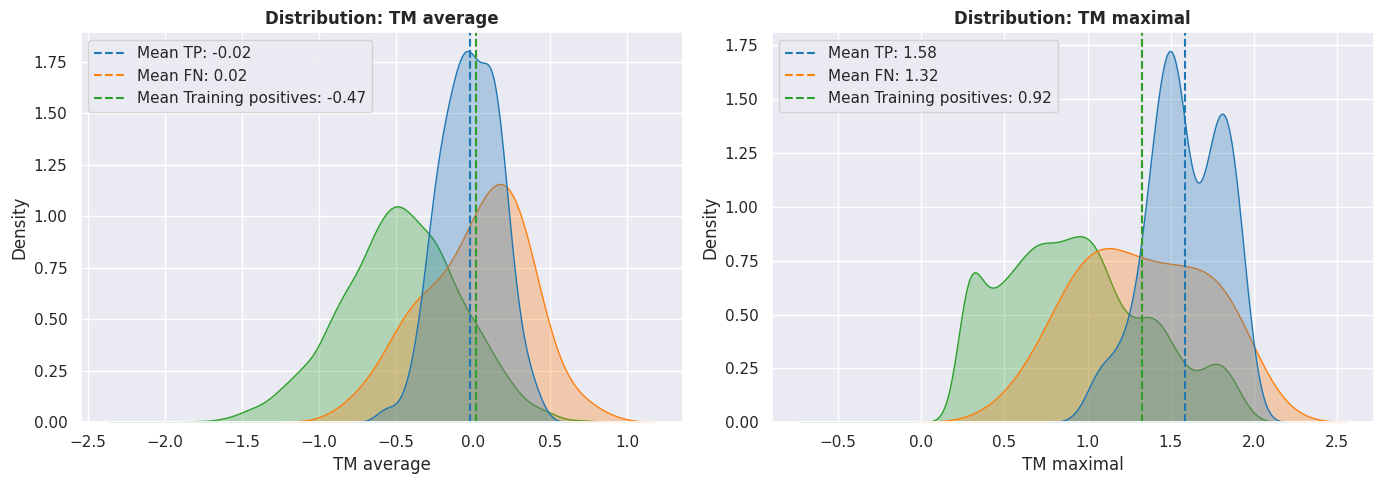

In [57]:
# Creiamo una griglia 1 riga x 3 colonne
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1, 2
plot_feature_comparison(axes[0], 'TM average', tp, fn, df)
plot_feature_comparison(axes[1], 'TM maximal', tp, fn, df)


plt.tight_layout()
plt.savefig("TM_distributions_comparison.png")
plt.show()